## Priprava podatkov
Uvoz knjiznic ter priprava podatkov. Podatke filtriramo tako, da vzamemo samo tržne posle.

**Opomba glede TRZNOST_POSLA:** leta 2021 in 2022 je GURS vse tržne posle kodiral s kodo `2` namesto `1` (sprememba šifranta). Zato vključimo obe kodi, sicer nam manjkata celi dve leti podatkov.

Podatkom dodamo skupen atribut `cena_m2` s katerim primerjamo cene.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# sep=None -> pandas sam ugotovi separator (vejica ali podpicje)
df = pd.read_csv("vse.csv", sep=None, engine="python")

df["DATUM"] = pd.to_datetime(df["DATUM_SKLENITVE_POGODBE"], errors="coerce", dayfirst=True)

# kodi 1 in 2 sta oba trzna posla (2021-2022 je GURS kodiral s 2)
df = df[
    (df["TRZNOST_POSLA"].isin([1, 2])) &
    (df["POGODBENA_CENA_ODSKODNINA"] > 0) &
    (df["PRODANA_POVRSINA"] > 5)
].copy()

df["cena_m2"] = df["POGODBENA_CENA_ODSKODNINA"] / df["PRODANA_POVRSINA"]

print(f"Stevilo zapisov: {len(df):,}")

Stevilo zapisov: 94,611


S spodnjo kodo odstranimo osamelce.

In [2]:
Q1 = df["cena_m2"].quantile(0.25)
Q3 = df["cena_m2"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["cena_m2"] >= lower) & (df["cena_m2"] <= upper)]
df = df[df["cena_m2"] < 10000]

df["leto"] = df["DATUM"].dt.year
df["mesec"] = df["DATUM"].dt.month

print(f"Po ciscenju: {len(df):,} zapisov")
print(f"Leta: {sorted(df['leto'].dropna().unique().astype(int))}")

Po ciscenju: 77,813 zapisov
Leta: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


Graf prikazuje gibanje mediane cen nepremičnin skupaj s številom sklenjenih poslov.

Opazimo:
- izrazito rast cen (približno 100–150%)
- hkraten padec števila poslov (~68%)

To nakazuje na zmanjšanje likvidnosti trga ob hkratni rasti cen, kar je lahko posledica makroekonomskih dejavnikov (inflacija, obrestne mere).

Drugi graf pa prikazuje razliko v ceni vseh občin oz. vseh brez Ljubljane.

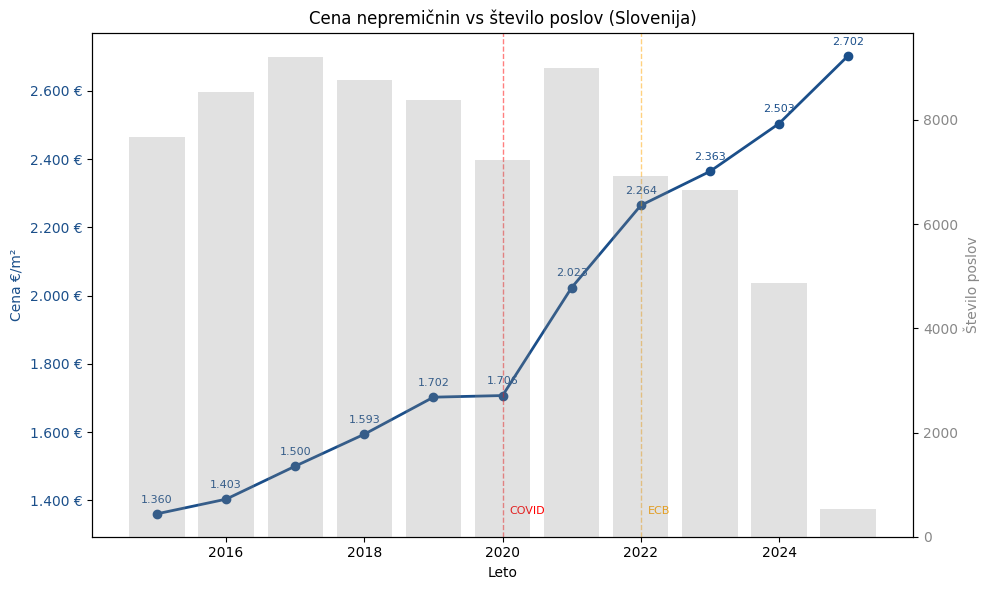

In [3]:
trend_slo = df.groupby("leto")["cena_m2"].median().reset_index()
counts = df.groupby("leto").size().reset_index(name="stevilo_poslov")
trend_slo = trend_slo.merge(counts, on="leto")

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(trend_slo["leto"], trend_slo["cena_m2"],
         marker="o", color="#1B4F8A", lw=2, label="Mediana €/m²")
ax1.set_ylabel("Cena €/m²", color="#1B4F8A")
ax1.set_xlabel("Leto")
ax1.tick_params(axis="y", labelcolor="#1B4F8A")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,} €".replace(",", ".")))

ax2 = ax1.twinx()
ax2.bar(trend_slo["leto"], trend_slo["stevilo_poslov"],
        alpha=0.25, color="#888888", label="Število poslov")
ax2.set_ylabel("Število poslov", color="#888888")
ax2.tick_params(axis="y", labelcolor="#888888")

# oznake vrednosti nad crto
for _, r in trend_slo.iterrows():
    ax1.annotate(f"{int(r['cena_m2']):,}".replace(",", "."),
                 (r["leto"], r["cena_m2"]), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8, color="#1B4F8A")

# ključni dogodki
ax1.axvline(2020, color="red", lw=1, ls="--", alpha=0.5)
ax1.text(2020.1, trend_slo["cena_m2"].min(), "COVID", fontsize=8, color="red")
ax1.axvline(2022, color="orange", lw=1, ls="--", alpha=0.5)
ax1.text(2022.1, trend_slo["cena_m2"].min(), "ECB", fontsize=8, color="orange")

plt.title("Cena nepremičnin vs število poslov (Slovenija)")
plt.tight_layout()
plt.show()

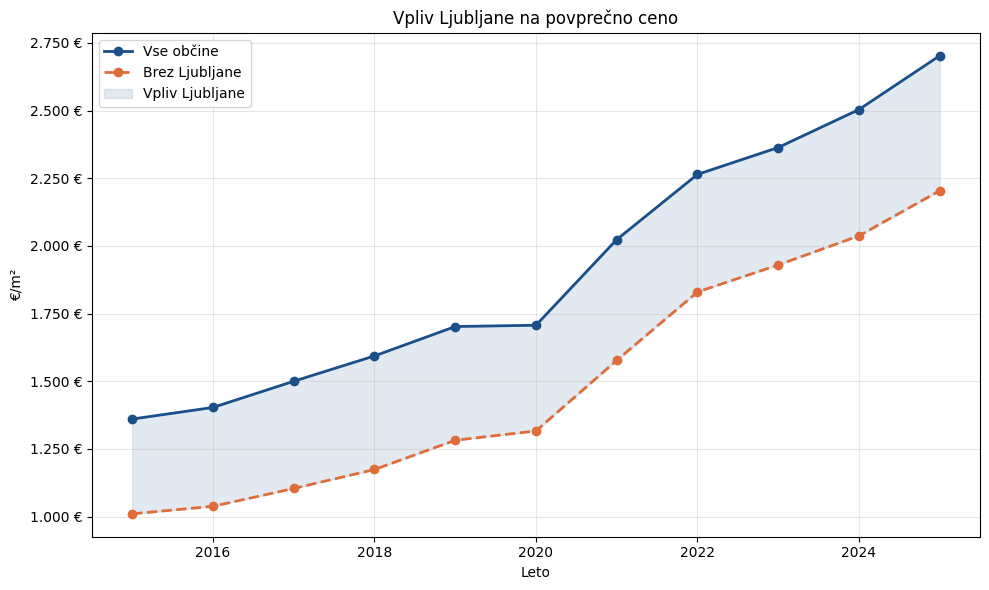

In [4]:
df_no_lj = df[df["OBCINA"] != "LJUBLJANA"]
trend_no_lj = df_no_lj.groupby("leto")["cena_m2"].median().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(trend_slo["leto"], trend_slo["cena_m2"],
         marker="o", label="Vse občine", color="#1B4F8A", lw=2)
plt.plot(trend_no_lj["leto"], trend_no_lj["cena_m2"],
         marker="o", label="Brez Ljubljane", color="#E06C3A", lw=2, ls="--")

# osenčena razlika
skupaj = trend_slo.merge(trend_no_lj, on="leto", suffixes=("_vse", "_brezlj"))
plt.fill_between(skupaj["leto"], skupaj["cena_m2_brezlj"], skupaj["cena_m2_vse"],
                 alpha=0.12, color="#1B4F8A", label="Vpliv Ljubljane")

plt.legend()
plt.title("Vpliv Ljubljane na povprečno ceno")
plt.ylabel("€/m²")
plt.xlabel("Leto")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,} €".replace(",", ".")))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
obcine = [
    'CELJE', 'DOMŽALE', 'KAMNIK', 'KOPER', 'KRANJ',
    'LJUBLJANA', 'MARIBOR', 'NOVA GORICA', 'NOVO MESTO', 'VELENJE'
]

trend_obcine = df.groupby(["leto", "OBCINA"])["cena_m2"].median().reset_index()
counts_obcine = df.groupby(["leto", "OBCINA"]).size().reset_index(name="n")
trend_obcine = trend_obcine.merge(counts_obcine, on=["leto", "OBCINA"])
trend_obcine = trend_obcine[trend_obcine["n"] >= 5]

Graf prikazuje razlike v cenah nepremičnin med občinami.

Opazimo:
- Ljubljana močno izstopa kot najdražja
- večina občin sledi podobnemu trendu rasti
- Nova Gorica ima nižjo rast (~80%) v primerjavi z drugimi (~100–150%)

Lokacija je tako ključni dejavnik pri določanju cene.

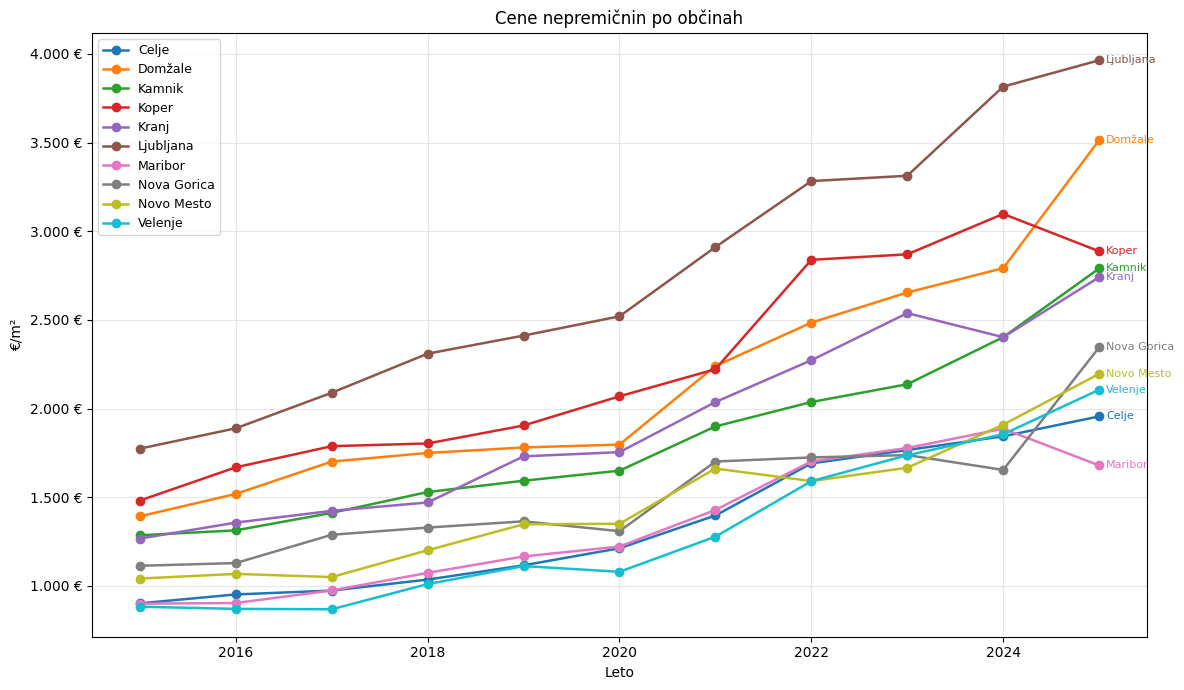

In [6]:
# barvna paleta za 10 občin
barve = plt.cm.tab10.colors

plt.figure(figsize=(12, 7))

for i, obcina in enumerate(obcine):
    subset = trend_obcine[trend_obcine["OBCINA"] == obcina]
    plt.plot(subset["leto"], subset["cena_m2"],
             marker="o", label=obcina.title(), color=barve[i], lw=1.8)
    # oznaka na zadnji točki
    if not subset.empty:
        zadnja = subset.sort_values("leto").iloc[-1]
        plt.annotate(obcina.title(),
                     xy=(zadnja["leto"], zadnja["cena_m2"]),
                     xytext=(5, 0), textcoords="offset points",
                     fontsize=8, color=barve[i], va="center")

plt.title("Cene nepremičnin po občinah")
plt.ylabel("€/m²")
plt.xlabel("Leto")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,} €".replace(",", ".")))
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Graf prikazuje relativno rast cen glede na začetno leto.

Opazimo:

- večina občin je dosegla 100–150% rast
- rast ni enakomerna med vsemi občinami
- manjše razlike postanejo bolj vidne kot pri absolutnih cenah


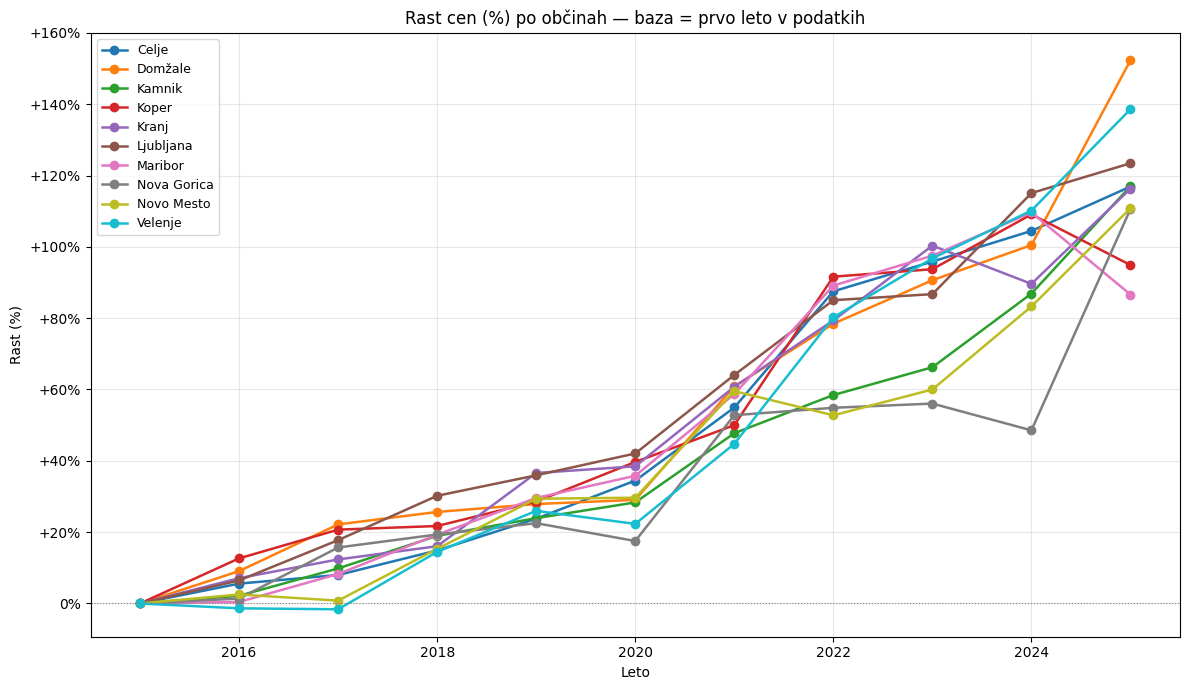

In [7]:
trend_obcine = trend_obcine.sort_values(["OBCINA", "leto"])

trend_obcine["rast_%"] = trend_obcine.groupby("OBCINA")["cena_m2"].transform(
    lambda x: (x / x.iloc[0] - 1) * 100
)

plt.figure(figsize=(12, 7))

for i, obcina in enumerate(obcine):
    subset = trend_obcine[trend_obcine["OBCINA"] == obcina]
    plt.plot(subset["leto"], subset["rast_%"],
             marker="o", label=obcina.title(), color=barve[i], lw=1.8)

plt.axhline(0, color="gray", lw=0.8, ls=":")
plt.title("Rast cen (%) po občinah — baza = prvo leto v podatkih")
plt.ylabel("Rast (%)")
plt.xlabel("Leto")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"+{int(x)}%" if x > 0 else f"{int(x)}%"))
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Graf združuje tri dimenzije:

- cena
- velikost nepremičnin
- število poslov

Opazimo:

- večja mesta imajo več poslov (večji mehurčki)
- manjše nepremičnine imajo višjo ceno na m²
- trg je zelo heterogen med občinami


/opt/miniconda3/envs/PRvaje/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


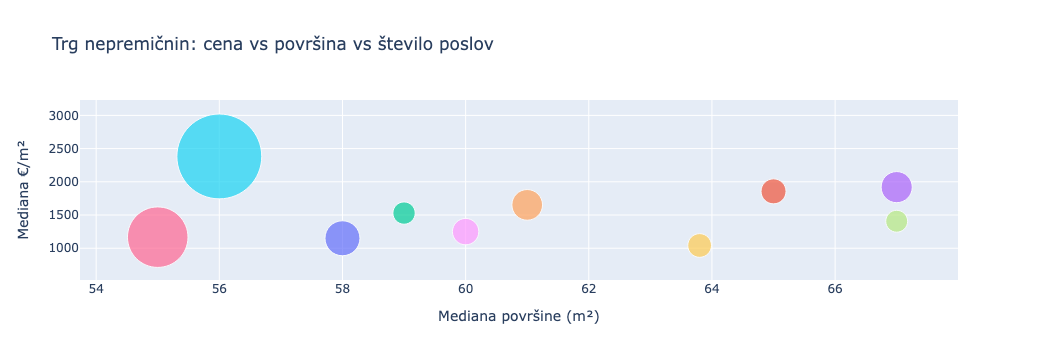

In [8]:
bubble = df.groupby("OBCINA").agg(
    povrsina=("PRODANA_POVRSINA", "median"),
    cena=("cena_m2", "median"),
    posli=("cena_m2", "count")
).reset_index()

# samo občine z vsaj 50 posli, da ne prikazujemo šuma
bubble = bubble[bubble["posli"] >= 50]

fig = px.scatter(
    bubble,
    x="povrsina",
    y="cena",
    size="posli",
    color="OBCINA",
    title="Trg nepremičnin: cena vs površina vs število poslov",
    hover_name="OBCINA",
    hover_data={"posli": True, "povrsina": ":.0f", "cena": ":.0f"},
    labels={"povrsina": "Mediana površine (m²)", "cena": "Mediana €/m²"},
    size_max=60
)
fig.update_layout(showlegend=False)
fig.show()

Heatmap omogoča hitro vizualno primerjavo cen med občinami in leti.

Opazimo:

- konstantno rast cen (temnejše barve)
- izrazito višje vrednosti v večjih mestih
- obdobja brez podatkov (luknje), kjer ni bilo poslov


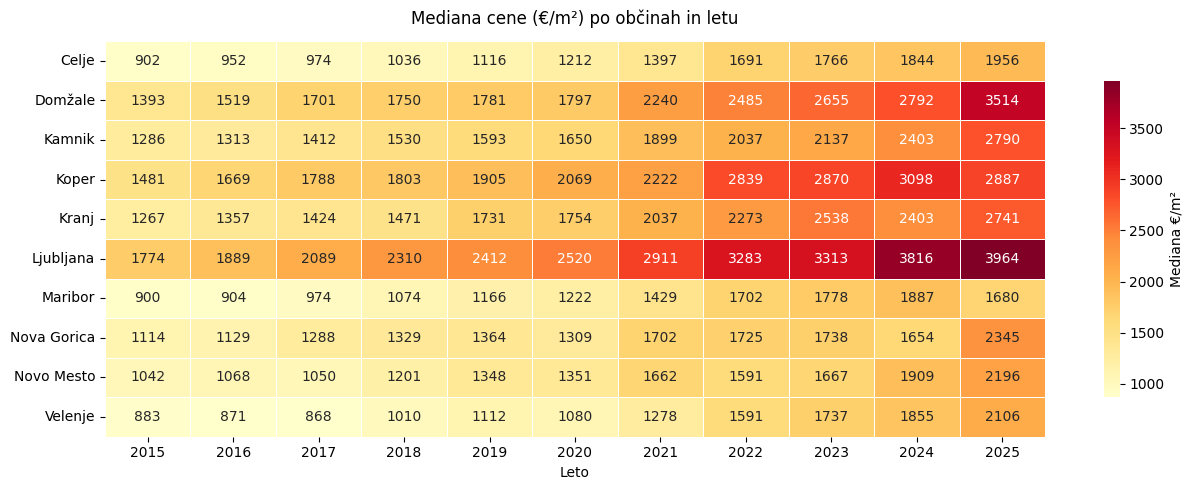

In [9]:
pivot = trend_obcine[trend_obcine["OBCINA"].isin(obcine)].pivot(
    index="OBCINA", columns="leto", values="cena_m2"
)
pivot.index = [o.title() for o in pivot.index]

fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    pivot, cmap="YlOrRd", ax=ax,
    annot=True, fmt=".0f",       # vrednosti v celicah
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Mediana €/m²", "shrink": 0.8}
)

ax.set_title("Mediana cene (€/m²) po občinah in letu", pad=12)
ax.set_xlabel("Leto")
ax.set_ylabel("")
plt.tight_layout()
plt.show()